# 04 — Training Model ResNet50


Notebook ini bertugas untuk melatih arsitektur ResNet50 dengan teknik transfer learning menggunakan dataset daun tanaman obat. Proses ini mengimpor fungsi-fungsi utama (Data Loader, Model, Config) secara langsung dari struktur backend App/.


### [CELL 1] - Import Libraries
<br><sub>**Maksud & Tujuan:** Memuat library bawaan Python, 	orch (PyTorch) untuk Deep Learning, serta memanggil fungsi bawaan kita dari pp/services/ dan konfigurasi dari pp/utils/config.py. Hal ini menjaga notebook tetap rapi dan terpusat.</sub>

In [1]:
import os
import sys
import json
import time
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models

# Tambahkan path backend ke sys.path
BASE_DIR = Path.cwd().parent  # backend/
sys.path.insert(0, str(BASE_DIR))

from app.services.preprocessing import get_data_loaders, get_class_names
from app.models.cnn_models import create_resnet50
from app.utils.config import (
    MODEL_RESNET_DIR, REPORTS_EVAL_DIR, MODEL_RESNET_DIR,
    BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, DEVICE
)

print(f"🖥️  Device: {DEVICE}")
print(f"📂 Base directory: {BASE_DIR}")

🖥️  Device: cpu
📂 Base directory: d:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend


### [CELL 2] - Load Data
<br><sub>**Maksud & Tujuan:** Memanggil get_data_loaders() dari services/preprocessing.py. Fungsi ini bertugas menarik gambar dari Folder Dataset untuk disuapkan ke model.<br>**Cara Kerjanya:** Gambar yang ditarik akan langsung di-**Augmentasi On-The-Fly** (diputar, dibalik, diberi efek pergeseran warna/cahaya secara instan di RAM tanpa menduplikat ukuran file di harddisk) dan dibaginya menjadi (80% Train, 20% Test) rata per *Batch*.
<br>**Kenapa ukuran Batch Size nya 32?** Angka 32 (atau 16, 64) adalah standar ukuran kelipatan bit yang dioptimalkan secara arsitektur untuk *memory/VRAM GPU/RAM* komputer modern. Kalau kekecilan latihannya lama, kalau kebesaran (misal 512) memori RAM akan langsung jebol dan laptop macet (*Out of Memory*).</sub>

In [2]:
train_loader, test_loader = get_data_loaders(batch_size=BATCH_SIZE)
class_names = get_class_names()
num_classes = len(class_names)

print(f"\n📊 Dataset Info:")
print(f"   Jumlah kelas: {num_classes}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ Combined dataset sudah ada: 98 kelas

📊 Dataset Info:
   Total gambar: 12845
   Total kelas:  98
   Train: 10276 gambar (80%)
   Test:  2569 gambar (20%)
   Train batches: 322
   Test batches:  81
✅ Combined dataset sudah ada: 98 kelas

📊 Dataset Info:
   Jumlah kelas: 98
   Train batches: 322
   Test batches: 81


### [CELL 3] - Buat Model ResNet50
<br><sub>**Maksud & Tujuan:** Menginisialisasi otak buatan yang kokoh, tajam, dan brutal. 
<br>**Bagaimana Algoritma ResNet50 bekerja?**<br>ResNet (*Residual Network*) dengan kedalaman 50 lapisan layar merupakan raksasa pemenang kompetisi AI legendaris. ResNet membawa inovasi bernama **Skip Connection** (*Jalan Pintas/Residual Block*). Jaman dahulu, kalau insinyur menumpuk otak AI sampai 50 layer dalamnya, arus matematika (*Gradient*) akan luntur jadi nol (*Vanishing Gradient*) sebelum sanggup nembus ke lapisan dasar-bawah waktu di training. Tapi **ResNet membuat jalan pintas by-pass matematika** dari lapisan awal bisa loncat langsung numpang jalur bebas ke lapisan setelahnya. 
<br>Hasilnya? Kita bisa menumpuk puluhan neural network jadi SAAAAAAANGAT DALUUUUUUM, dan Model ini mampu **membaca serat tulang daun secara super kompleks dan teliti**. Meskipun bayarannya ukuran MB modelnya akan lumayan gemuk sedikit lebih lama memproses (*Inference Time*) ketimbang abangnya MobileNet! Sangat memuaskan jika akurasi adalah segala-galanya!
<br>**Kenapa Pretrained=True?** Agar tidak usah mengajar ResNet cara melihat benda dan garis dasar. Kita tingal pakai otaknya dan ganti pelatuk akhirnya saja meramal nama spesies dedaunan medikal India ini.</sub>

In [5]:
model = create_resnet50(num_classes=num_classes, pretrained=True)
model = model.to(DEVICE)

# Hitung total parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n🧠 Model: ResNet50")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Frozen parameters: {total_params - trainable_params:,}")


🧠 Model: ResNet50
   Total parameters: 23,708,834
   Trainable parameters: 23,708,834
   Frozen parameters: 0


### [CELL 4] - Definisi Loss, Optimizer, Scheduler
<br><sub>**Maksud & Tujuan:** Mengatur parameter 'Aturan Main' selama masa model belajar.
<br>**Kenapa CrossEntropyLoss(weight=...)?** Ini adalah Rumus Hukuman. Kita sengaja menyuntikkan daftar *Class Weights* JSON kita ke sini. Jadi, kalau AI salah menebak daun mayoritas, model dipukul ringan. Tapi kalau salah nebak daun super langka yg gambarnya dikit, model dipukul puluhan kali secara penalti matematik! Otomatis kelakuan model jadi jauh lebih seimbang dan adil (tidak rasis ke daun yang banyak datanya).
<br>**Kenapa Algoritma Optimizernya pakai Adam(lr=0.001)?** Adam itu algoritma mesin pencari titik nol kesalahan yang punya 'Momentum'. Ibarat bola menuruni bukit lembah salah, Adam bisa lari kencang. lr=0.001 (*Learning Rate*) adalah ukuran 'lebar langkah kaki'-nya. Kalau kebesaran model jalannya melompat lompat ngawur, kalau terlalu kecil jadinya super lambat. weight_decay=1e-4 adalah **rem blong (Regularisasi L2)** supaya model nggak sekadar 'menhafal mati' tapi beneran 'belajar pola'.
<br>**Kenapa Scheduller StepLR(step_size=7, gamma=0.1)?** Fitur ini bertugas mengecilkan lambatnya *Learning Rate* (dikorting jadi 0.1/10%-nya) tiap berlalu **7 Epoch**. Ibarat main Golf: pas jarak target jauh pukulnya keras-keras, giliran hampir sampai sasaran akhir, pukulnya pelan-pelan supaya jatuhnya sempurna bola di lubang.
<br>**Kenapa Epochs=25?** Satu Epoch itu = AI telah tuntas melihat SELURUH gambar dari 100+ spesies di Dataset sebanyak 1 putaran. 25 putaran (*Epoch*) adalah angka 'Golden Rule' rata-rata hemat untuk Transfer Learning. Di atas putaran segitu, model biasanya mentok alias *Overfitting* (pamer IPK gede padahal cuma jago hafalan, dipakai ke dunia nyata jawabnya salah total).</sub>

In [6]:
# ---------------------------------------------------------
# PENAMBAHAN CLASS WEIGHTS DARI HASIL PREPROCESSING
# ---------------------------------------------------------
import json
import torch

metadata_path = BASE_DIR / 'reports' / 'preprocessing' / 'preprocessing_metadata.json'
if metadata_path.exists():
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
        print('✅ Membaca metadata Preprocessing... OTW inject Class Weights!')
        
    weights_dict = metadata.get('class_weights', {})
    
    weights_list = [weights_dict.get(c, 1.0) for c in class_names]
    weight_tensor = torch.tensor(weights_list, dtype=torch.float32).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    print(f'✅ Weighted CrossEntropyLoss diaktifkan untuk {len(class_names)} kelas.')
else:
    print('⚠️ preprocessing_metadata.json tidak ditemukan! Menjalankan mode normal (tanpa bobot).')
    criterion = nn.CrossEntropyLoss()
# ---------------------------------------------------------

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print(f"\n⚙️  Training Config:")
print(f"   Loss function: CrossEntropyLoss (Weighted)")
print(f"   Optimizer: Adam (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"   Scheduler: StepLR (step_size=7, gamma=0.1)")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")


✅ Membaca metadata Preprocessing... OTW inject Class Weights!
✅ Weighted CrossEntropyLoss diaktifkan untuk 98 kelas.

⚙️  Training Config:
   Loss function: CrossEntropyLoss (Weighted)
   Optimizer: Adam (lr=0.001, weight_decay=1e-4)
   Scheduler: StepLR (step_size=7, gamma=0.1)
   Epochs: 25
   Batch size: 32


### [CELL 5] - Training Loop
<br><sub>**Maksud & Tujuan:** Menggiring model masuk ke kelas mesin belajar yang mutar-mutar sesuai jumlah epoch. Di tiap *epoch*nya punya dua fase ketat:
1. **Train Phase (model.train())**: Model nebak gambar, nilainya dicatat (loss), lalu kabel kabel sel otaknya langsung diperbaiki lewat koreksi balik/Backpropagation (loss.backward() & optimizer.step()).
2. **Val/Test Phase (model.eval())**: Model hanya diijinkan murni menjawab Ujian Akhir tanpa dituntun dosen. Kabel otaknya DILARANG DIREVISI, buat uji mental doang. 
<br>**Kenapa dipasang variabel est_model_wts?** Sering terjadi model itu ngeraih IPK terbaik misal pada *Epoch* ke-14, tapi abis itu saking jenuhnya dia grafiknya terjun bebas jadi goblok lagi di *Epoch* 25. Nah script ini pintar sekali, setiap melihat IPK tertinggi pecah rekor baru, memori jaringannya langsung auto-disekap (di-save di memori buffer). Akhirnya cuma masa jaya modelnya saja yang diselamatkan!</sub>

In [7]:
def train_model(model, criterion, optimizer, scheduler, train_loader, test_loader,
                num_epochs, device, model_name="resnet50"):
    """
    Training loop dengan early stopping dan penyimpanan model terbaik.
    """
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'epoch_time': [], 'lr': []
    }
    
    print(f"\n{'='*60}")
    print(f"🏋️  Mulai Training: {model_name.upper()}")
    print(f"{'='*60}\n")
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0
        
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)
        
        train_loss = running_loss / total_samples
        train_acc = running_corrects.double() / total_samples
        
        # --- Test/Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                val_total += inputs.size(0)
        
        val_loss = val_loss / val_total
        val_acc = val_corrects.double() / val_total
        
        scheduler.step()
        epoch_time = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]['lr']
        
        # Simpan history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())
        history['epoch_time'].append(epoch_time)
        history['lr'].append(current_lr)
        
        # Print progress
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"Time: {epoch_time:.1f}s | LR: {current_lr:.6f}")
        
        # Simpan model terbaik
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"   💾 Model terbaik disimpan! (Val Acc: {best_acc:.4f})")
    
    print(f"\n{'='*60}")
    print(f"✅ Training selesai!")
    print(f"   Best Validation Accuracy: {best_acc:.4f}")
    print(f"   Total training time: {sum(history['epoch_time']):.1f}s")
    print(f"{'='*60}")
    
    # Load model terbaik
    model.load_state_dict(best_model_wts)
    
    return model, history

model, history = train_model(
    model, criterion, optimizer, scheduler,
    train_loader, test_loader,
    num_epochs=NUM_EPOCHS, device=DEVICE,
    model_name="resnet50"
)


🏋️  Mulai Training: RESNET50

Epoch [1/25] Train Loss: 4.4597 Acc: 0.0238 | Val Loss: 4.1266 Acc: 0.0494 | Time: 2941.3s | LR: 0.001000
   💾 Model terbaik disimpan! (Val Acc: 0.0494)
Epoch [2/25] Train Loss: 3.9109 Acc: 0.0799 | Val Loss: 3.5700 Acc: 0.1059 | Time: 3228.4s | LR: 0.001000
   💾 Model terbaik disimpan! (Val Acc: 0.1059)
Epoch [3/25] Train Loss: 3.4127 Acc: 0.1460 | Val Loss: 3.4925 Acc: 0.1440 | Time: 3171.3s | LR: 0.001000
   💾 Model terbaik disimpan! (Val Acc: 0.1440)
Epoch [4/25] Train Loss: 3.0238 Acc: 0.2197 | Val Loss: 2.5916 Acc: 0.2865 | Time: 3107.9s | LR: 0.001000
   💾 Model terbaik disimpan! (Val Acc: 0.2865)
Epoch [5/25] Train Loss: 2.7284 Acc: 0.2744 | Val Loss: 3.7681 Acc: 0.1740 | Time: 2941.9s | LR: 0.001000
Epoch [6/25] Train Loss: 2.4907 Acc: 0.3236 | Val Loss: 2.0598 Acc: 0.3994 | Time: 2971.0s | LR: 0.001000
   💾 Model terbaik disimpan! (Val Acc: 0.3994)
Epoch [7/25] Train Loss: 2.1413 Acc: 0.3980 | Val Loss: 1.9549 Acc: 0.4476 | Time: 3095.4s | LR: 0

### [CELL 6] - Simpan Model & History
<br><sub>**Maksud & Tujuan:** Menyimpan fisik parameter model terbaik hasil kurungan buffer dari sel 5 ke wujud nyata alias file ber-ekstensi .pth. Model format .pth inilah yang bisa di-eksport lalu ditaruh dicodingan API FastAPI nanti ke FrontEnd! File history.json-nya simpan statistik Epoch guna menggambar plot kurvanya.</sub>

In [8]:
model_path = os.path.join(MODEL_RESNET_DIR, "resnet50_best.pth")
torch.save(model.state_dict(), model_path)
print(f"💾 Model disimpan ke: {model_path}")
print(f"   Ukuran file: {os.path.getsize(model_path) / (1024*1024):.1f} MB")

history_path = os.path.join(MODEL_RESNET_DIR, "resnet50_history.json")
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"📄 History disimpan ke: {history_path}")

💾 Model disimpan ke: D:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\trained_models\resnet50\resnet50_best.pth
   Ukuran file: 90.7 MB
📄 History disimpan ke: D:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\trained_models\resnet50\resnet50_history.json


### [CELL 7] - Visualisasi Training History
<br><sub>**Maksud & Tujuan:** Menilai kualitas grafis sihir dari jaring saraf. Grafik yang sehat (*Best Curve*) itu bila garis Train Accuracy dan Validation Accuracy **naik harmonis** beriringan, sedngkan angka Loss-nya **menukik landai asik** beriringan ke angka paling nol bareng. Kalau satu melayang naik satu nyungsep menjauh, wahai saudara.. itu namanya *Overfitting* yang jelek sekali.</sub>

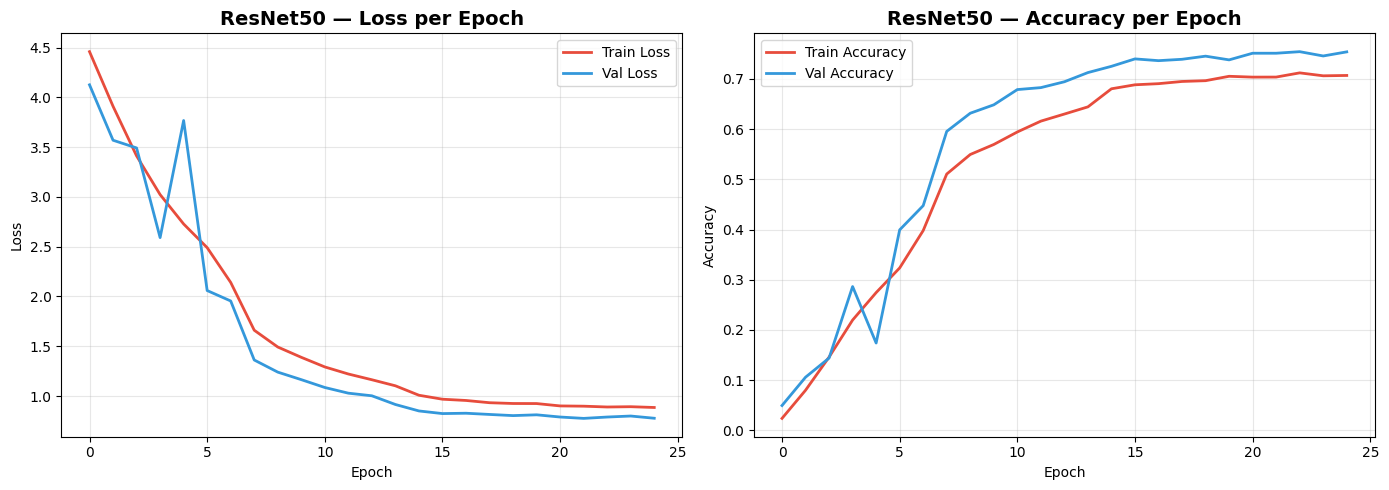

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', color='#3498db', linewidth=2)
axes[0].set_title('ResNet50 — Loss per Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Accuracy', color='#e74c3c', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', color='#3498db', linewidth=2)
axes[1].set_title('ResNet50 — Accuracy per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_EVAL_DIR, MODEL_RESNET_DIR, 'training_history_resnet50.png'), dpi=150, bbox_inches='tight')
plt.show()

### [CELL 8] - Quick Evaluation on Test Set
<br><sub>**Maksud & Tujuan:** Ini kayak tryout kilat instan kilat terakhir setelah kelulusan model. Kita cuma pengin liat **Total % Acc** nya berapa sama butuh waktu hitungan ms (*Miliseconds*) per tebakannya seberapa tokcer. Untuk grafik-grafikan super lengkapnya bakal dibantai habis di buku **05_model_comparison**.</sub>

In [10]:
model.eval()
test_corrects = 0
test_total = 0
inference_times = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        start_time = time.time()
        outputs = model(inputs)
        inference_times.append(time.time() - start_time)
        
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)
        test_total += inputs.size(0)

test_acc = test_corrects.double() / test_total
avg_inference = np.mean(inference_times) * 1000

print(f"\n📊 Quick Test Evaluation — ResNet50")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Avg Inference Time: {avg_inference:.2f} ms/batch")
print(f"   Model Size: {os.path.getsize(model_path) / (1024*1024):.1f} MB")
print(f"\n   → Evaluasi detail dilakukan di 05_model_comparison.ipynb")


📊 Quick Test Evaluation — ResNet50
   Test Accuracy: 0.7544 (75.44%)
   Avg Inference Time: 1995.20 ms/batch
   Model Size: 90.7 MB

   → Evaluasi detail dilakukan di 05_model_comparison.ipynb
